# EDA

In [19]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [132]:
# Data Load

df = pd.read_csv("../dataset/train.csv")

df.head(50)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [94]:
# Stats

print(df.describe())

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  


In [95]:
# Null Values

print(df.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


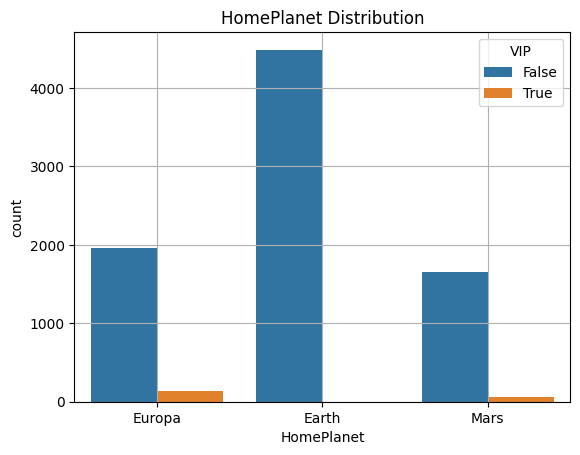

In [96]:
# HomePlanet Distribution

sns.countplot(
    x = "HomePlanet" ,
    hue = "VIP" ,
    data = df
)

plt.title("HomePlanet Distribution")
plt.grid()
plt.show()

# We can clearly see that all the VIP's are from either Europa or Mars .
# Earth planet contributes highest passengers

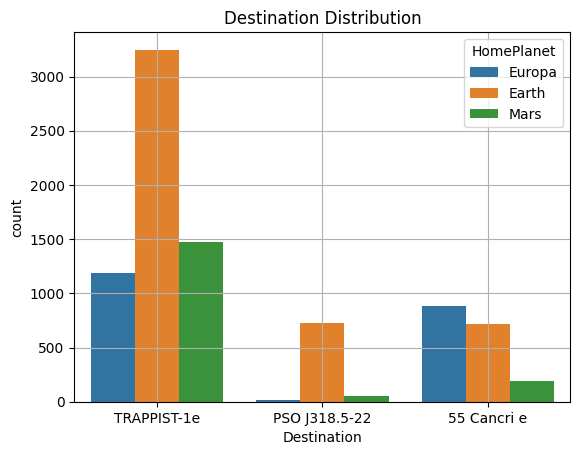

In [127]:
# Destination Distribution

sns.countplot(
    x = "Destination" ,
    hue = "HomePlanet" ,
    data = df
)

plt.title("Destination Distribution")
plt.grid()
plt.show()

In [123]:
# Filling Null Values

df["Expense"] = df["RoomService"] + df["FoodCourt"] + df["ShoppingMall"] + df["Spa"] + df["VRDeck"]

expense_column = ["RoomService"	,
                  "FoodCourt" ,
                  "ShoppingMall" ,
                  "Spa" ,
                  "VRDeck"
]
for i in expense_column :
    df.loc[(df["CryoSleep"] == True) & (df[i].isnull()) , i] = 0.0

df.loc[(((df["HomePlanet"] == "Europa") | (df["HomePlanet"] == "Mars")) & (df["VIP"].isnull())) , "VIP"] = True
df.loc[((df["HomePlanet"] == "Earth") & (df["VIP"].isnull())) , "VIP"] = False

df.loc[((df["VIP"] == False) & (df["HomePlanet"].isnull())) , "HomePlanet"] = "Earth"

df.loc[((df["Expense"] == 0.0) & (df["CryoSleep"].isnull())) , "CryoSleep"] = True
df.loc[((df["Expense"] != 0.0) & (df["CryoSleep"].isnull())) , "CryoSleep"] = False

In [124]:
print(df.isnull().sum())

PassengerId       0
HomePlanet        8
CryoSleep         0
Cabin           199
Destination     182
Age             179
VIP               3
RoomService     113
FoodCourt       113
ShoppingMall    112
Spa             118
VRDeck          126
Name            200
Transported       0
Expense         561
dtype: int64


In [ ]:
# Fill all expense column with median (different for vip and non vip)